# Log Odds Ratio Test Plots

Generates log odds ratio test plots found in [Fig. 5](figures/figure_5) and the [Supplementary Figures](figures/supplementary)

## Notebook Workflow

1. Load stage-05 odds-ratio result pickle files.
2. Generate the main odds-ratio distribution and summary plots.
3. Produce supplementary variants used in figure panels.
4. Save final figure outputs with publication settings.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

%load_ext autoreload
%autoreload 2

import importlib
import odds_ratio_test as ort
import odds_ratio_test_plotting as ortplot

print("odds_ratio_test:", ort.__file__)
print("odds_ratio_test_plotting:", ortplot.__file__)

importlib.reload(ortplot)
importlib.reload(ort)

figure5 = os.path.join(repo_root, "figures", "figure_5")
supp = os.path.join(repo_root, "figures", "supplementary")


Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
odds_ratio_test: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup/odds_ratio_test.py
odds_ratio_test_plotting: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup/odds_ratio_test_plotting.py


/Users/calvin/anaconda3/envs/orb-selection/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%autoreload 2

ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Jul22/Run1_occ_30-88_10000x")
results = ort.PermulationTestResults.load_from_pickle(f"{ort_dir}/results.pkl")

In [6]:
def count_duplicates(results):

    for label, arr in [("loss", results.means_loss), ("dup", results.means_dup)]:
        values, counts = np.unique(arr, return_counts=True)
        dupe_group_counts = counts[counts > 1]
        print(f"{label}: unique means = {len(values)} of {len(arr)}")
        print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
        print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
        if len(dupe_group_counts):
            print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
        print()

In [7]:
from collections import Counter
from pathlib import Path
import json

from Bio import Phylo
import matplotlib.pyplot as plt


def plot_most_reused_permulation_tree(
    results_obj,
    newick_path,
    fig_width=12,
    per_tip_height=0.22,
    title_prefix="Most re-used permulation",
):
    """Plot a Newick tree with tip labels annotated by the most frequent permulation tip-value map."""
    items = results_obj.permulation_tip_values
    serialized = [json.dumps(d, sort_keys=True, default=str) for d in items]
    counts = Counter(serialized)

    most_common_serialized, most_common_count = counts.most_common(1)[0]
    most_common_dict = json.loads(most_common_serialized)

    tree = Phylo.read(str(newick_path), "newick")
    tree_tip_names = {t.name for t in tree.get_terminals()}
    value_tip_names = set(most_common_dict.keys())

    missing_in_values = sorted(tree_tip_names - value_tip_names)
    missing_in_tree = sorted(value_tip_names - tree_tip_names)

    print(f"Total permulations: {len(items)}")
    print(f"Unique tip-value maps: {len(counts)}")
    print(f"Most duplicated map count: {most_common_count}")
    print(f"Tree tips: {len(tree_tip_names)}")
    print(f"Dictionary keys: {len(value_tip_names)}")
    print(f"Tips missing values: {len(missing_in_values)}")
    print(f"Dictionary keys not in tree: {len(missing_in_tree)}")

    if missing_in_values:
        print("Example missing values:", missing_in_values[:10])
    if missing_in_tree:
        print("Example keys not in tree:", missing_in_tree[:10])

    def format_tip_label(clade):
        if not clade.is_terminal():
            return None
        value = most_common_dict.get(clade.name, "NA")
        if isinstance(value, (int, float)) and float(value).is_integer():
            value = int(value)
        return f"{clade.name}: {value}"

    fig_height = max(8, len(tree_tip_names) * per_tip_height)
    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_subplot(111)
    Phylo.draw(tree, axes=ax, do_show=False, label_func=format_tip_label)
    ax.set_title(f"{title_prefix} (n={most_common_count})")
    plt.tight_layout()
    plt.show()

    return most_common_dict, most_common_count

## Results

### Loss

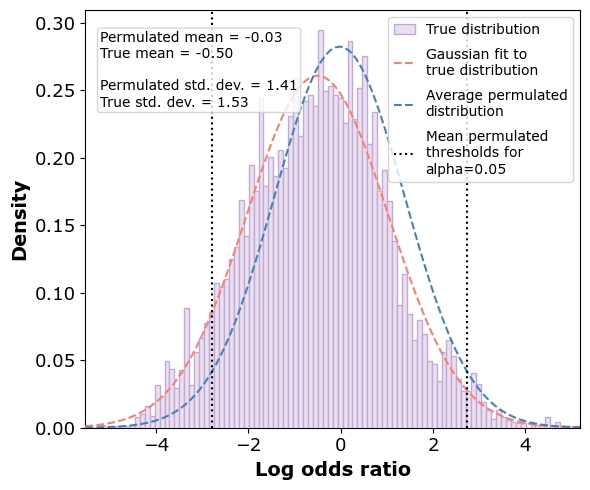

In [ ]:
%autoreload 2
ortplot.plot_permulation_results(
    results,
    "loss",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermulation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=10,
    textbox_fontsize=10,
    axis_label_fontsize=14,
 )

plt.savefig(os.path.join(figure5, "loss_results.png"), dpi=300, bbox_inches="tight", transparent=True)

### Duplication

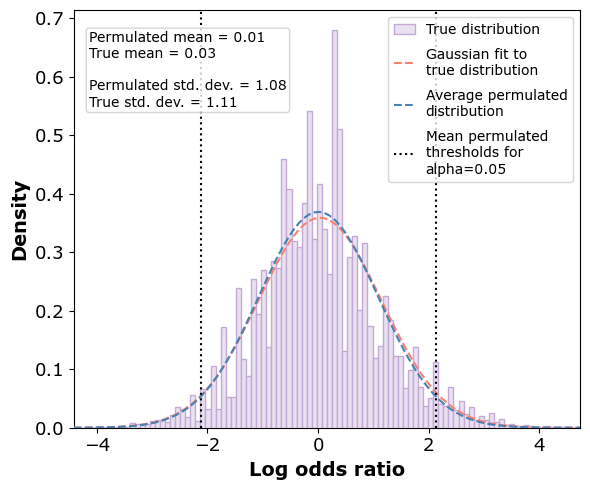

In [9]:
%autoreload 2
ortplot.plot_permulation_results(
    results,
    "duplication",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermulation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=10,
    textbox_fontsize=10,
    axis_label_fontsize=14
)

plt.savefig(os.path.join(figure5, "dup_results.png"), dpi=300, bbox_inches="tight", transparent=True)

## Loss permuted stats

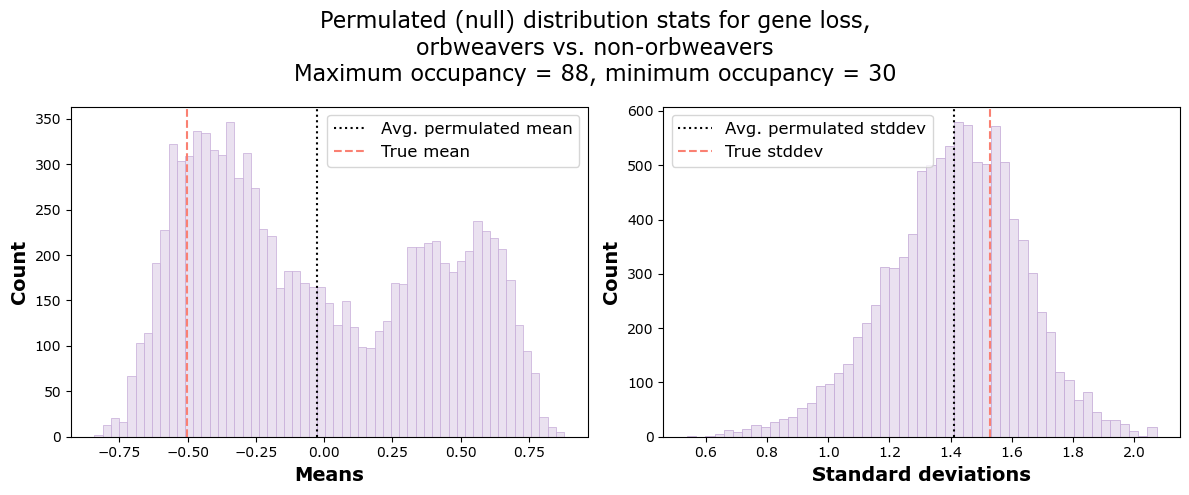

In [10]:
%autoreload 2
ortplot.plot_permulation_stats(
    results,
    "loss",
    # hist_color="black",
    # edgecolor="black",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=True,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=True,
    # xlim=(-1.2, 1.2),
    # split_y_axis=True,
    # split_y_lims=((0, 600), (1150, 1250)),
    binwidth=0.03
 )

plt.savefig(os.path.join(supp, "loss_single_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

In [11]:
count_duplicates(results)

loss: unique means = 9942 of 10000
loss: duplicate mean groups = 24
loss: entries in duplicate mean groups = 82
loss: largest duplicate group size = 17

dup: unique means = 9942 of 10000
dup: duplicate mean groups = 24
dup: entries in duplicate mean groups = 82
dup: largest duplicate group size = 17



### Investigating most common repeated permulated tree

Total permulations: 10000
Unique tip-value maps: 9942
Most duplicated map count: 17
Tree tips: 103
Dictionary keys: 98
Tips missing values: 5
Dictionary keys not in tree: 0
Example missing values: ['Antrodiaetus_roretzi', 'Drosophila_melanogaster', 'Falcileptoneta_japonica', 'Masirana_silvicola', 'Orchestina_okitsui']


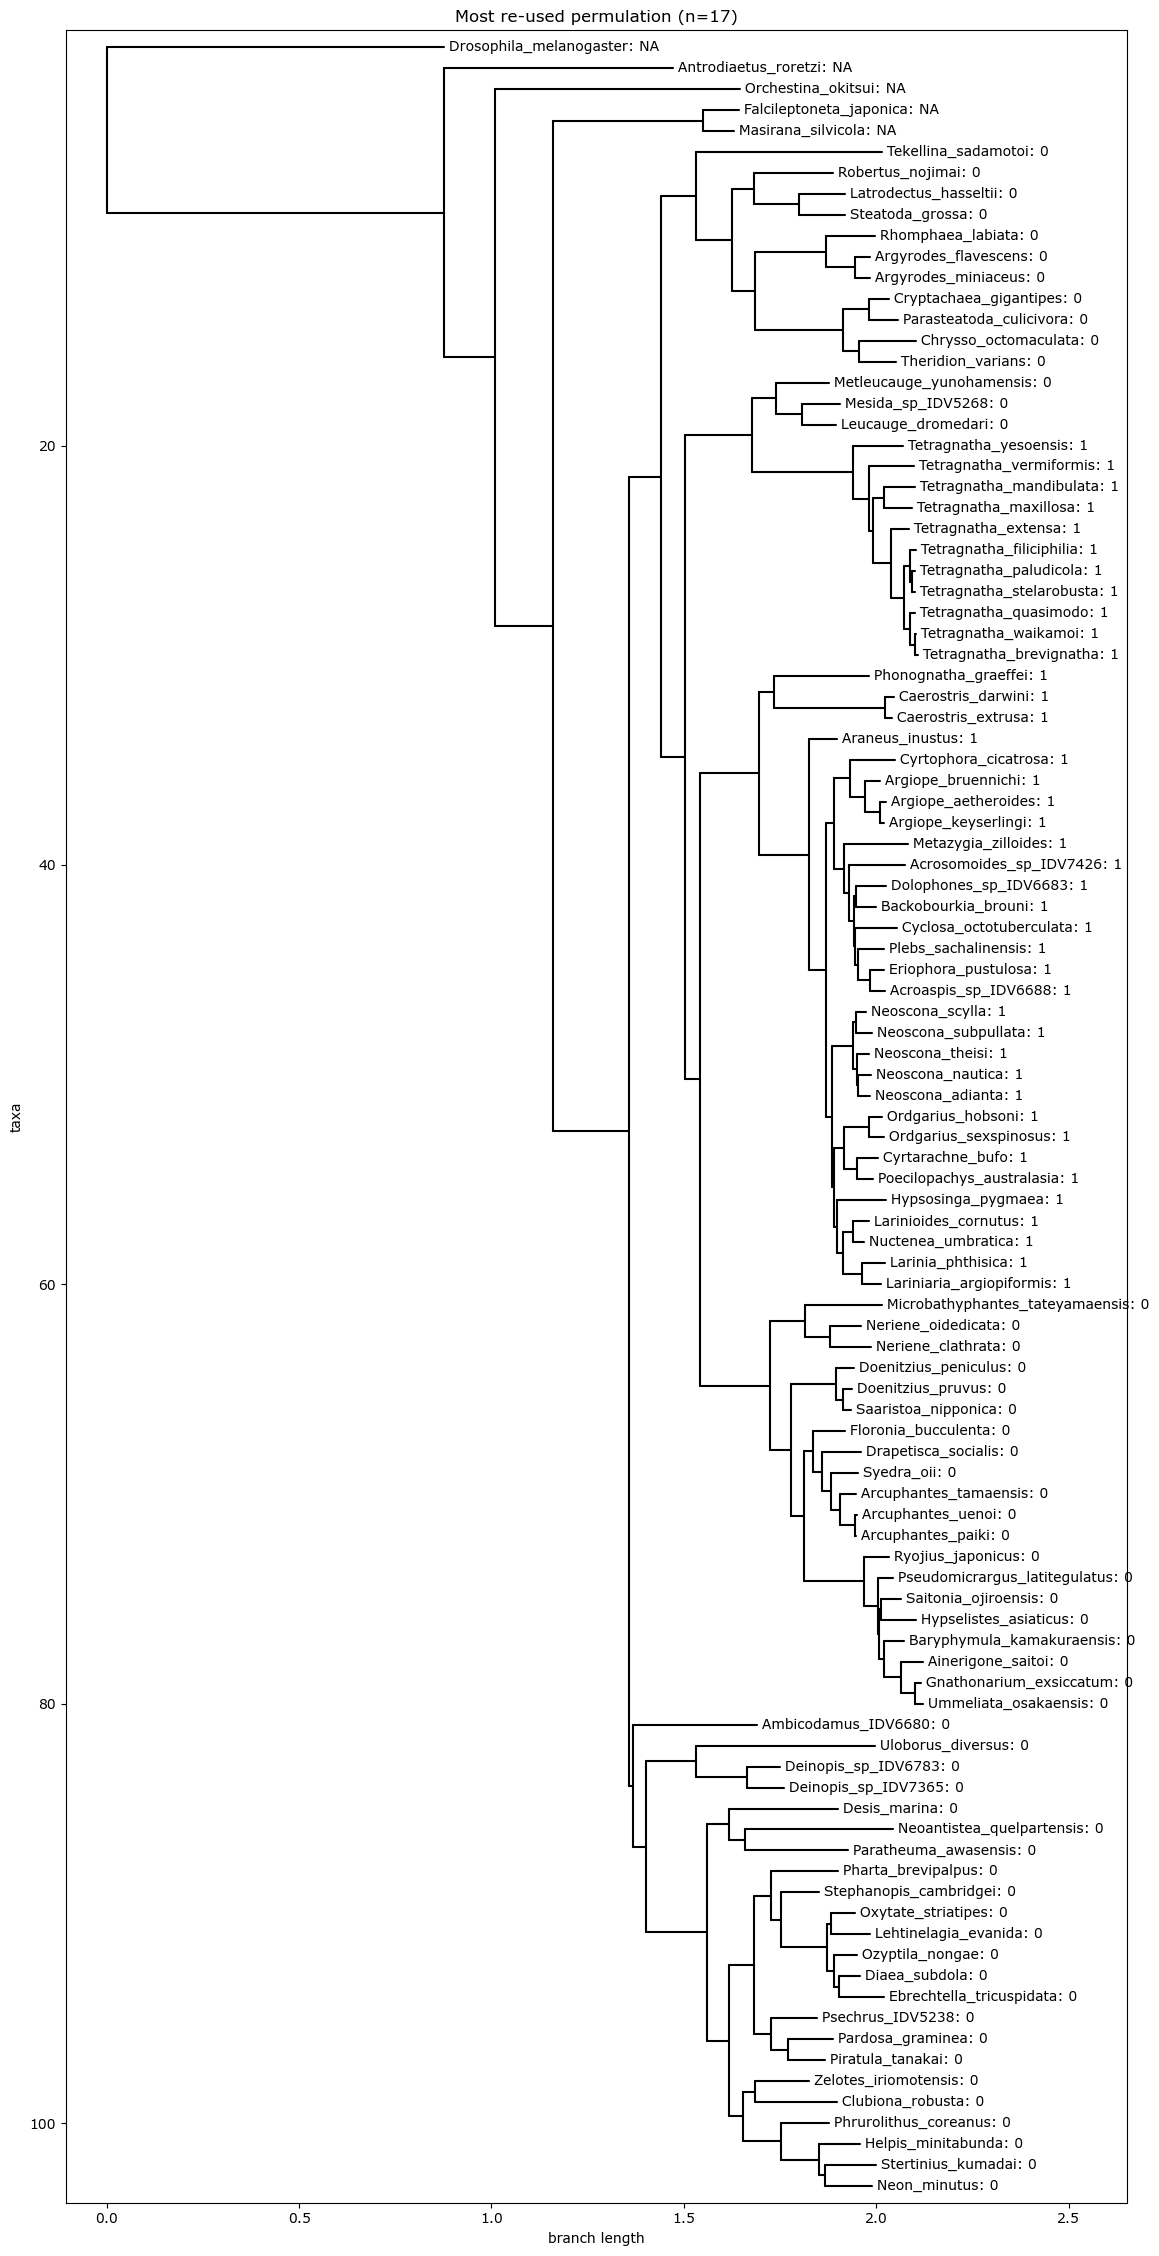

17

In [12]:
newick_path = Path(repo_root) / "data" / "SpeciesTree_full_brlen.nwk"

most_common_dict, most_common_count = plot_most_reused_permulation_tree(
    results,
    newick_path,
)
most_common_count

## Duplication permuted stats

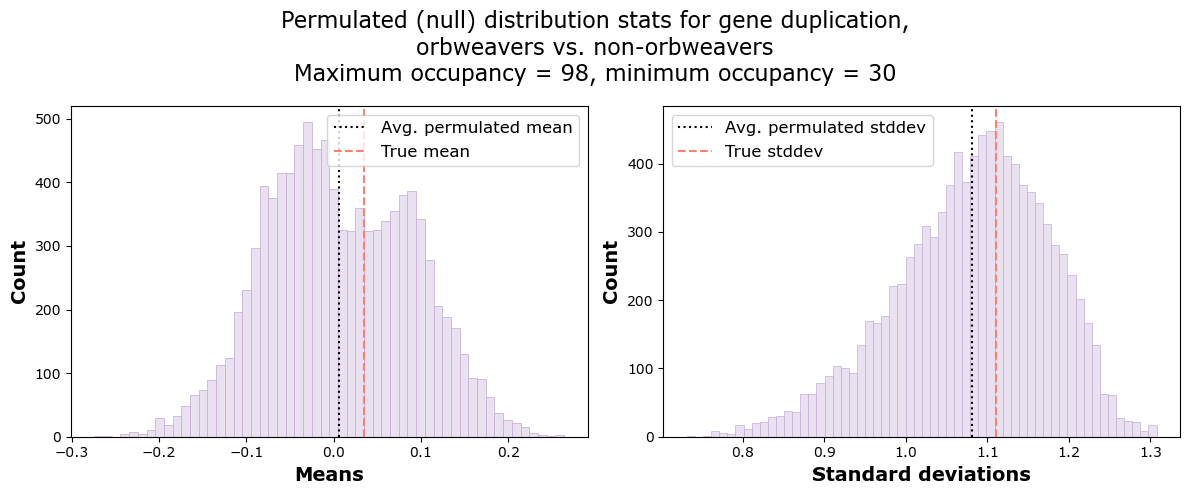

In [ ]:

%autoreload 2
ortplot.plot_permulation_stats(
    results,
    "duplication",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    hist_alpha=1,
    title=True,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=True,
    binwidth=0.01
 )

plt.savefig(os.path.join(supp, "dup_single_stats.png"), dpi=300, bbox_inches="tight", transparent=True)